# Measured architecture

Read RSML file and run a simulation of the sap flux from an Arabidopsis de-topped root plunged in a hydroponic solution at a hydrostatic pressure of 0.4 Mpa when its  base is at the atmospheric pressure.

In [6]:
from openalea import hydroroot
from openalea.hydroroot.main import hydroroot_flow
# from openalea.hydroroot import hydro_io
from openalea.widgets.plantgl import PlantGL # notebook viewer 3D
from openalea.plantgl.algo.view import view # 2D view

## RSML to MTG
1. Read the rsml file and convert it to a MTG g of segments of 0.1 mm

In [7]:
g = hydro_io.read_rsml('plant-01.rsml', segment_length=1.0e-4)

2. Set the root radii
   The radius setting follows the Arabidopsis model describeded in Boursiac et al. 2022. The root radius is set according to the radius of the primary root $r_{ref}$ and the order of the lateral as follows: $r_{lat} = \beta^{order} r_{ref}$. $\beta$ is the radius decreasing facteur between root orders.

In [8]:
g = hydroroot.radius.ordered_radius(g, 7.0e-5, 0.7) # primary root radius 7.0e-5 m, beta = 0.7
g = hydroroot.radius.compute_relative_position(g) # Compute the position of each segment relative to the axis bearing it

## Set hydraulic properties

In [9]:
k_radial_data=([0, 0.2],[30.0,30.0]) # radial conductivity profile: distance to tip (m) vs kr (10-9 m.s-1.MPa-1)
K_axial_data=([0, 0.2],[3.0e-7,4.0e-4]) # axial conductance profile: distance to tip (m) vs Kx (10-9 m4.s-1.MPa-1)

## Flux and equivalent conductance calculation

for a detopped root in a hydroponic medium at 0.4 MPa, its base at 0.1 MPa.

In [10]:
g, keq, jv = hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, 
                            axial_conductivity_data = K_axial_data, 
                            radial_conductivity_data = k_radial_data)

Print resuls

In [11]:
print('equivalent root conductance (10-9 m3/s/MPa): ',keq, 'sap flux (microL/s): ', jv)

equivalent root conductance (10-9 m3/s/MPa):  0.009596381061843703 sap flux (microL/s):  0.002878914318553111


## Plots

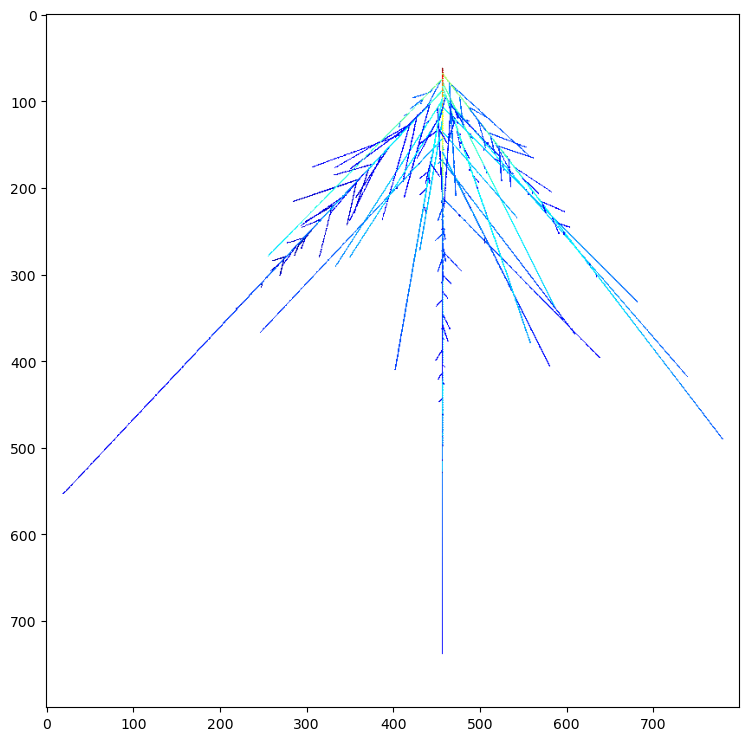

/home/bauget/Documents/Dev/hydroroot/src/openalea/hydroroot/display.py:290: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


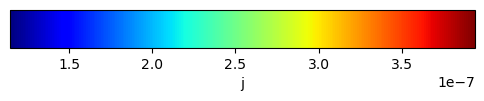

In [12]:
s = hydroroot.display.mtg_scene(g, prop_cmap = 'j') # create a scene from the mtg with the property j is the radial flux in ul/s
# PlantGL(s) # display the root into the plantgl oawidget
view(s) # view in 2D
hydroroot.display.property_scale_bar(g, 'j')

## Changing radial conductivity
You may change the radial conductivity and see the impact on the water uptake

sap flux (microL/s):  0.010609107156851389


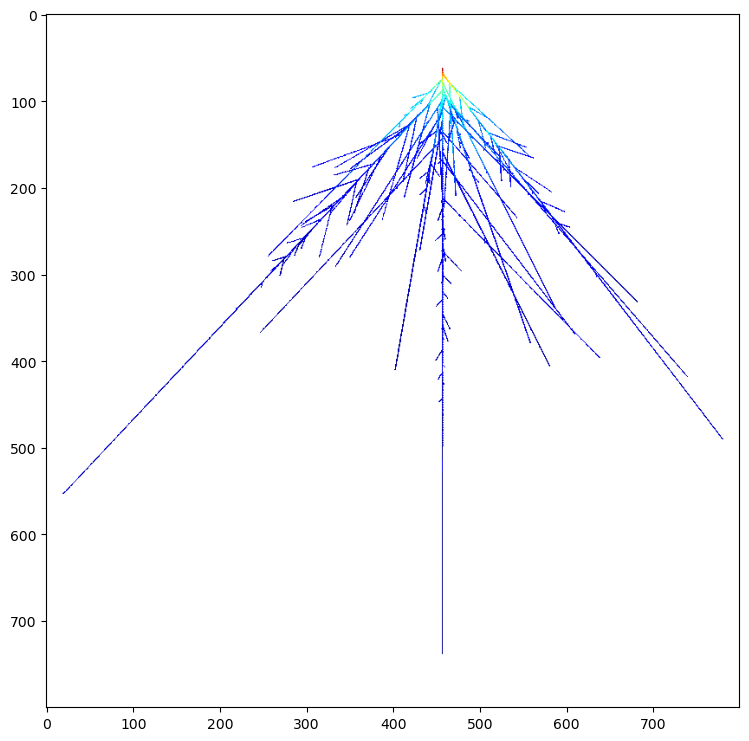

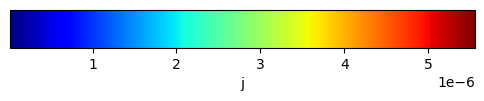

In [18]:
k_radial_data=([0, 0.2],[300.0,300.0])
g, keq, jv = hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, axial_conductivity_data = K_axial_data, radial_conductivity_data = k_radial_data)
print('sap flux (microL/s): ', jv)
s = hydroroot.display.mtg_scene(g, prop_cmap='j')
view(s) # to reduce notebook size we use here a 2D view but use PlantGL(s) to 3D
hydroroot.display.property_scale_bar(g, 'j')

## Changing axial conductance

sap flux (microL/s):  0.0019166890917623359


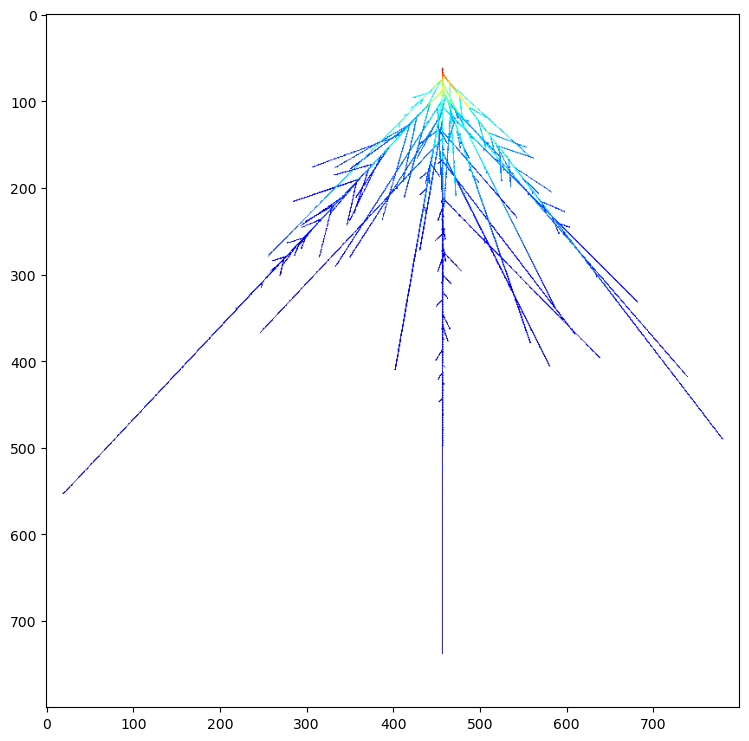

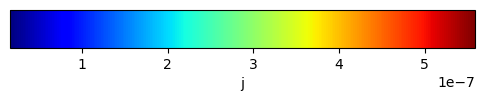

In [19]:
k_radial_data=([0, 0.2],[30.0,30.0])
K_axial_data=([0, 0.2],[3.0e-7,1.0e-4])
g, keq, jv = hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, axial_conductivity_data = K_axial_data, radial_conductivity_data = k_radial_data)
print('sap flux (microL/s): ', jv)
s = hydroroot.display.mtg_scene(g, prop_cmap='j')
view(s) # to reduce notebook size we use here a 2D view but use PlantGL(s) to 3D
hydroroot.display.property_scale_bar(g, 'j')

## PlantGl viewer

This is only working on **local machine**.

HydroRoot has also a function using the standalone Plantgl viewer allowing to specify the mtg property.

The following will open a standalone window with a 3D representation of the root. Uncomment the lines to run the cell locally.

In [12]:
# %gui qt
# hydroroot.display.plot(g, prop_cmap='psi_in')